In [1]:
# ========== JAX PRECISION CONFIGURATION ==========
# MUST be set BEFORE importing jax or any jax-using modules!
import jax
import jax.numpy as jnp

# Set to True for float64 (safer for atmospheric modeling)
# Set to False for float32 (faster but may overflow/NaN)
USE_FLOAT64 = True

jax.config.update("jax_enable_x64", USE_FLOAT64)
DTYPE = jnp.float64 if USE_FLOAT64 else jnp.float32

print("="*70)
print(f"JAX Configuration:")
print(f"  Precision: {'float64' if USE_FLOAT64 else 'float32'}")
print(f"  Device: {jax.devices()[0]}")
print(f"  Default dtype: {jnp.array(1.0).dtype}")
print("="*70)

JAX Configuration:
  Precision: float64
  Device: cuda:0
  Default dtype: float64


# JAX vs TauREx Forward Model Comparison

This notebook compares the JAX differentiable forward model with the standard TauREx implementation, including a full fitting workflow.

**IMPORTANT**: JAX precision must be configured BEFORE importing any JAX code!

In [2]:
# ========== IMPORTS ==========
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import time
# JAX already imported in precision config cell
import jax.scipy as jsp
import optax
from functools import partial
from typing import Dict, Tuple, Any

import taurex.log
taurex.log.disableLogging()

from taurex.cache import OpacityCache,CIACache
from taurex.contributions import AbsorptionContribution, CIAContribution, RayleighContribution
from taurex.data.spectrum.observed import ObservedSpectrum
from taurex.model import TransmissionModel

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar
from taurex.chemistry import TaurexChemistry, ConstantGas
from taurex.temperature import Isothermal

from jax_backend import create_binned_forward_model, extract_fitting_params, clip_native_to_wngrid, create_forward_model
from jax_backend import full_diff_create_forward_model, full_diff_create_binned_forward_model

Numba not installed, using numpy instead


In [3]:
home_directory = os.path.expanduser('~')
xsec_path = f"{home_directory}/code/research/taurex3/test_files/xsec/xsec_sampled_R15000_0.3-50"
cia_path = f"{home_directory}/code/research/taurex3/test_files/cia/HITRAN/data"
obs_path  = f"{home_directory}/code/research/taurex3/examples/parfiles/quickstart.dat"

OpacityCache().clear_cache()
OpacityCache().set_opacity_path(xsec_path)
CIACache().set_cia_path(cia_path)


In [4]:
# Build TauREx model
planet = Planet(planet_radius=1.0, planet_mass=1.0)
star = BlackbodyStar(temperature=5700.0, radius=1.0)

chemistry = TaurexChemistry(fill_gases=['H2','He'], ratio=0.172)
chemistry.addGas(ConstantGas('H2O', mix_ratio=1.2e-4))
chemistry.addGas(ConstantGas('N2', mix_ratio=3.00739e-9))

isothermal = Isothermal(T=1500.0)

tm = TransmissionModel(
    planet=planet,
    temperature_profile=isothermal,
    chemistry=chemistry,
    star=star,
    atm_min_pressure=1e-0,
    atm_max_pressure=1e6,
    nlayers=30
)
tm.add_contribution(AbsorptionContribution())
tm.add_contribution(CIAContribution(cia_pairs=['H2-H2','H2-He']))
tm.add_contribution(RayleighContribution())
tm.build()
tm['H2O'] = 1.2e-4

In [5]:
chemistry.gases

['H2', 'He', 'H2O', 'N2']

In [6]:
print(f"Active gases: {list(tm.chemistry.activeGases)}")
print(f"Fill gases: {list(tm.chemistry._fill_gases)}")

Active gases: ['H2O']
Fill gases: ['H2', 'He']


In [8]:
# Load observations with correct dtype
obs = ObservedSpectrum(obs_path)

# Setup observed data (convert to target dtype)
obs_y = jnp.asarray(obs.spectrum, dtype=DTYPE)
if hasattr(obs, "errorBar"):
    obs_err = jnp.asarray(obs.errorBar, dtype=DTYPE)
else:
    obs_err = 0.02 * jnp.maximum(jnp.abs(obs_y), 1e-12)

print(f"Observation dtype: {obs_y.dtype}")
print(f"Error dtype: {obs_err.dtype}")

# Create binned forward model - THIS IS THE KEY MISSING PIECE
# forward_binned = create_binned_forward_model(tm, obs)
forward_binned = full_diff_create_binned_forward_model(tm, obs)

Observation dtype: float64
Error dtype: float64


In [13]:
obs.wavenumberGrid

array([ 2004.86565839,  2024.91431497,  2045.16345812,  2065.6150927 ,
        2086.27124363,  2107.13395607,  2128.20529563,  2149.48734858,
        2170.98222207,  2192.69204429,  2214.61896473,  2236.76515438,
        2259.13280592,  2281.72413398,  2304.54137532,  2327.58678907,
        2350.86265697,  2374.37128354,  2398.11499637,  2422.09614633,
        2446.3171078 ,  2470.78027888,  2495.48808166,  2520.44296248,
        2545.64739211,  2571.10386603,  2596.81490469,  2622.78305373,
        2649.01088427,  2675.50099311,  2702.25600305,  2729.27856308,
        2756.57134871,  2784.13706219,  2811.97843282,  2840.09821714,
        2868.49919932,  2897.18419131,  2926.15603322,  2955.41759355,
        2984.97176949,  3014.82148718,  3044.96970206,  3075.41939908,
        3106.17359307,  3137.235329  ,  3168.60768229,  3200.29375911,
        3232.2966967 ,  3264.61966367,  3297.26586031,  3330.23851891,
        3363.5409041 ,  3397.17631314,  3431.14807627,  3465.45955703,
      

In [8]:
high_res_wngrid = clip_native_to_wngrid(
    tm.nativeWavenumberGrid,
    obs.wavenumberGrid
)

# Ensure increasing order for safety
if high_res_wngrid[0] > high_res_wngrid[-1]:
    high_res_wngrid = high_res_wngrid[::-1]

bin_edges = obs.binEdges
if bin_edges[0] > bin_edges[-1]:
    bin_edges = bin_edges[::-1]

# 2) JAX forward model at high resolution
# jax_forward_model = create_forward_model(tm, high_res_wngrid)
jax_forward_model = full_diff_create_forward_model(tm, high_res_wngrid)

Pre-loading opacities for gases: ('H2O',)
Loading H2O opacity: T=27, P=22, WN=76744 (native resolution)


In [9]:
# Extract parameters with correct dtype
params, param_info = extract_fitting_params(tm, dtype=DTYPE)

In [10]:
full_absoprtion, full_tau = jax_forward_model(params)

In [10]:
obin = obs.create_binner()

In [12]:
taurex_full_absorption = tm.model(obs.wavenumberGrid)[1]

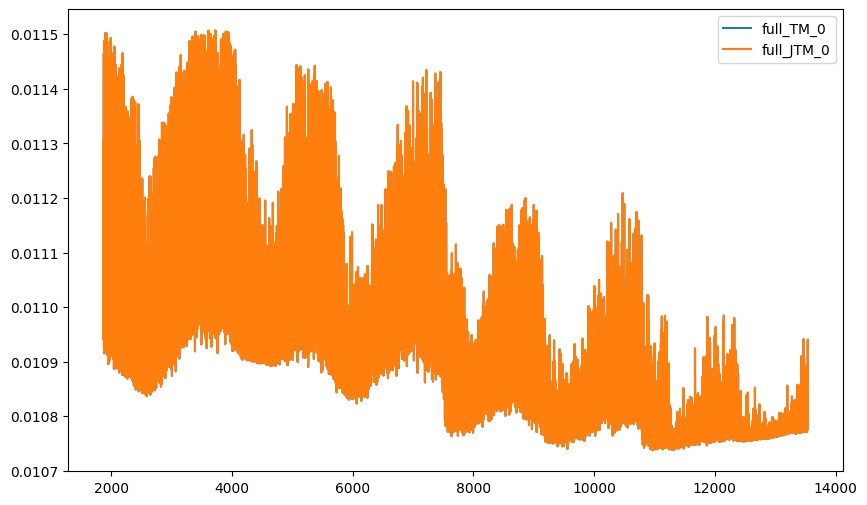

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(high_res_wngrid, taurex_full_absorption, label="full_TM_0")
plt.plot(high_res_wngrid, full_absoprtion, label="full_JTM_0")
plt.legend()
plt.show()

In [14]:
params

{'planet_mass': Array(1., dtype=float64),
 'planet_radius': Array(1., dtype=float64),
 'planet_distance': Array(1., dtype=float64),
 'planet_sma': Array(1., dtype=float64),
 'distance': Array(1., dtype=float64),
 'atm_min_pressure': Array(1., dtype=float64),
 'atm_max_pressure': Array(1000000., dtype=float64),
 'T': Array(1500., dtype=float64),
 'H2O': Array(0.00012, dtype=float64),
 'N2': Array(3.00739e-09, dtype=float64),
 'He_H2': Array(0.172, dtype=float64)}

In [15]:
tm_y = obin.bin_model(tm.model(obs.wavenumberGrid))[1]

jtm_y = np.array(forward_binned(params))

params['H2O'] = np.array(1e-4)
params['planet_radius'] = np.array(0.9777810779205119)
params['T'] = np.array(1496.606399794941)
jtm_y_fit = np.array(forward_binned(params))

tm['H2O'] = 1e-4
tm['planet_radius'] = 0.9777810779205119
tm['T'] = 1496.606399794941

tm_y_fit = obin.bin_model(tm.model(obs.wavenumberGrid))[1]

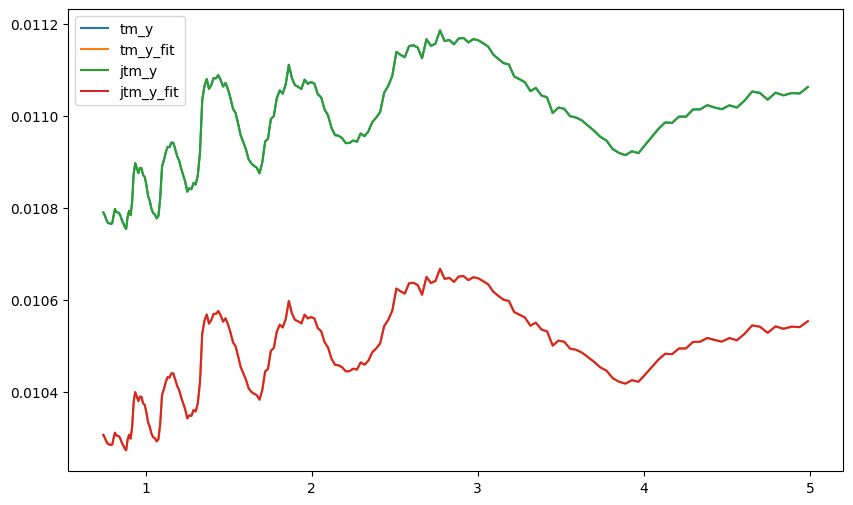

In [16]:
plt.figure(figsize=(10, 6))
# plt.errorbar(obs.wavelengthGrid, obs.spectrum, obs.errorBar, label='Obs')
plt.plot(obs.wavelengthGrid, tm_y, label='tm_y')
plt.plot(obs.wavelengthGrid, tm_y_fit, label='tm_y_fit')

plt.plot(obs.wavelengthGrid, jtm_y, label='jtm_y')
plt.plot(obs.wavelengthGrid, jtm_y_fit, label='jtm_y_fit')
plt.legend()
plt.show()

In [17]:
# Choose parameters to fit
fit_params = ['planet_radius', 'T', 'H2O']

print(f"Parameters to fit: {fit_params}")
print("\nInitial values:")
for k in fit_params:
    initial = float(params[k])
    print(f"  {k}: {initial:.6e}")

Parameters to fit: ['planet_radius', 'T', 'H2O']

Initial values:
  planet_radius: 9.777811e-01
  T: 1.496606e+03
  H2O: 1.000000e-04


## Optimization with Adam

Now we'll fit the selected parameters using gradient descent. The JAX configuration at the top ensures we use **float64 precision** to avoid:
- Overflow errors when casting large pressure values (~1e6 Pa)
- NaN gradients due to numerical instability in float32

In [18]:
# Import fitting function
from jax_backend import fit_with_value_and_grad_adam

# Run optimization
print("Starting optimization...")
final_params, losses = fit_with_value_and_grad_adam(
    forward_binned=forward_binned,
    observed_y=obs_y,
    observed_err=obs_err,
    init_params=params,
    param_info=param_info,
    fit_params=fit_params,
    steps=500,
    lr=1e-3,
    clip_norm=1.0,
    print_every=50,
    nan_guard=True,
    loss="mse",
)

print("\n✓ Optimization complete!")

Starting optimization...
step    0 | loss=0.100226 | ||grad||=4.022e+00
step   50 | loss=0.097644 | ||grad||=5.762e-02
step  100 | loss=0.0975727 | ||grad||=1.266e-02
step  150 | loss=0.0975726 | ||grad||=6.187e-04
step  200 | loss=0.0975726 | ||grad||=2.891e-05
step  250 | loss=0.0975726 | ||grad||=8.074e-06
step  300 | loss=0.0975726 | ||grad||=6.893e-07
step  350 | loss=0.0975726 | ||grad||=5.041e-08
step  400 | loss=0.0975726 | ||grad||=6.848e-05
step  450 | loss=0.0975807 | ||grad||=3.053e-01
step  499 | loss=0.0975727 | ||grad||=2.382e-02

✓ Optimization complete!


In [19]:
# Display results
print("="*70)
print("OPTIMIZATION RESULTS")
print("="*70)

for k in fit_params:
    initial = float(params[k])
    final = float(final_params[k])
    change = final - initial
    pct_change = (change / initial) * 100 if initial != 0 else 0
    print(f"{k:20s}: {initial:.6e} -> {final:.6e}")
    print(f"{'':20s}  Change: {change:+.6e} ({pct_change:+.2f}%)")

OPTIMIZATION RESULTS
planet_radius       : 9.777811e-01 -> 9.777061e-01
                      Change: -7.492896e-05 (-0.01%)
T                   : 1.496606e+03 -> 1.505610e+03
                      Change: +9.003966e+00 (+0.60%)
H2O                 : 1.000000e-04 -> 9.502757e-05
                      Change: -4.972425e-06 (-4.97%)


In [20]:
# Compute fitted spectra
initial_spectrum = np.array(forward_binned(params))
final_spectrum = np.array(forward_binned(final_params))

# Also compute TauREx spectra for validation
tm_initial_y = obin.bin_model(tm.model(obs.wavenumberGrid))[1]

# Update TauREx model with fitted parameters
for k in fit_params:
    tm[k] = float(final_params[k])
tm_final_y = obin.bin_model(tm.model(obs.wavenumberGrid))[1]

In [21]:
# # Compare JAX vs TauREx at fitted parameters
# abs_diff = np.abs(final_spectrum - tm_final_y)
# rel_diff = abs_diff / (tm_final_y + 1e-30)

# print("JAX vs TauREx Comparison (using fitted parameters):")
# print(f"  Max absolute difference: {np.max(abs_diff):.3e}")
# print(f"  Mean absolute difference: {np.mean(abs_diff):.3e}")
# print(f"  Max relative difference: {np.max(rel_diff):.3e}")
# print(f"  Mean relative difference: {np.mean(rel_diff):.3e}")

# if np.mean(rel_diff) < 0.01:
#     print("\n✓ JAX model matches TauREx to < 1%!")
# else:
#     print(f"\n⚠ Warning: JAX differs from TauREx by {np.mean(rel_diff)*100:.2f}%")

# # Plot the difference
# plt.figure(figsize=(12, 4))
# plt.plot(obs.wavelengthGrid, (final_spectrum - tm_final_y) / tm_final_y * 100, 
#          'o-', linewidth=2, markersize=5)
# plt.axhline(0, color='black', linestyle='--', alpha=0.5)
# plt.xlabel('Wavelength (μm)', fontsize=12)
# plt.ylabel('Relative Difference (%)', fontsize=12)
# plt.title('JAX - TauREx Difference (fitted parameters)', fontsize=13, fontweight='bold')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.legend()
# plt.show()

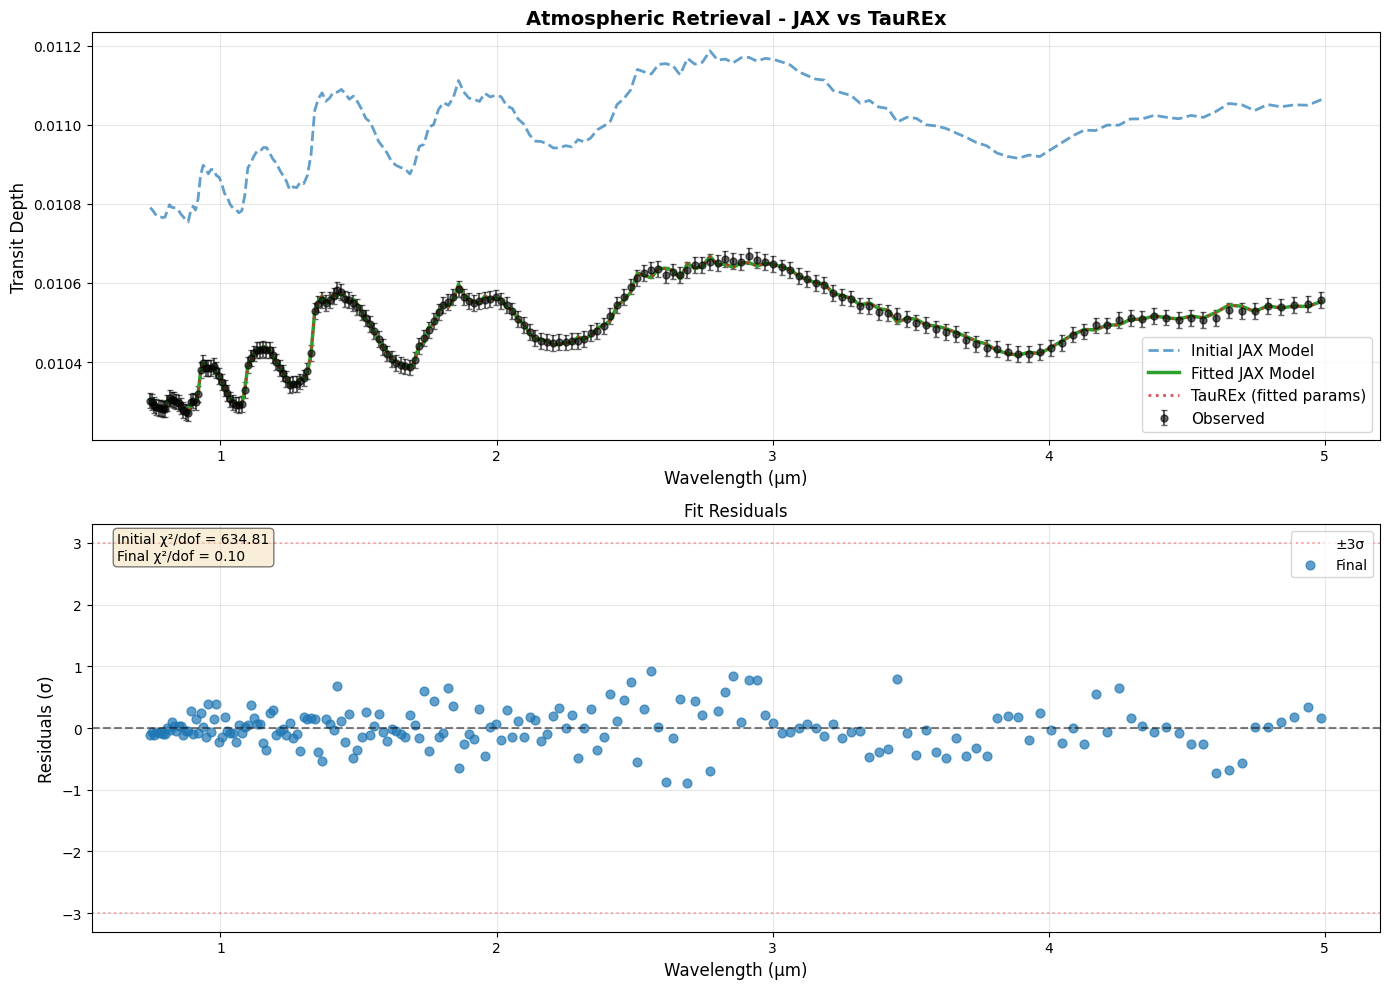


Fit quality: χ²/dof 634.81 → 0.10
RMS residuals: 0.31σ


In [27]:
# Plot comparison of observed vs fitted spectra
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: Spectra
ax = axes[0]
ax.errorbar(obs.wavelengthGrid, obs.spectrum, yerr=obs.errorBar if hasattr(obs, 'errorBar') else None,
            fmt='o', alpha=0.6, markersize=5, color='black',
            label='Observed', capsize=2)
ax.plot(obs.wavelengthGrid, jtm_y, '--', linewidth=2, alpha=0.7,
        label='Initial JAX Model')
ax.plot(obs.wavelengthGrid, final_spectrum, '-', linewidth=2.5,
        label='Fitted JAX Model', color='C2')
ax.plot(obs.wavelengthGrid, tm_final_y, ':', linewidth=2,
        label='TauREx (fitted params)', color='C3', alpha=0.8)
ax.set_xlabel('Wavelength (μm)', fontsize=12)
ax.set_ylabel('Transit Depth', fontsize=12)
ax.set_title('Atmospheric Retrieval - JAX vs TauREx', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Bottom: Residuals
ax = axes[1]
obs_err_array = obs.errorBar if hasattr(obs, 'errorBar') else 0.02 * np.abs(obs.spectrum)
initial_residuals = (obs.spectrum - jtm_y) / obs_err_array
final_residuals = (obs.spectrum - final_spectrum) / obs_err_array

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.axhline(3, color='red', linestyle=':', alpha=0.3, label='±3σ')
ax.axhline(-3, color='red', linestyle=':', alpha=0.3)

# ax.scatter(obs.wavelengthGrid, initial_residuals, alpha=0.5, s=40, label='Initial')
ax.scatter(obs.wavelengthGrid, final_residuals, alpha=0.7, s=40, label='Final')

ax.set_xlabel('Wavelength (μm)', fontsize=12)
ax.set_ylabel('Residuals (σ)', fontsize=12)
ax.set_title('Fit Residuals', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

chi2_initial = np.sum(initial_residuals**2) / len(initial_residuals)
chi2_final = np.sum(final_residuals**2) / len(final_residuals)
ax.text(0.02, 0.98, f'Initial χ²/dof = {chi2_initial:.2f}\nFinal χ²/dof = {chi2_final:.2f}',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nFit quality: χ²/dof {chi2_initial:.2f} → {chi2_final:.2f}")
print(f"RMS residuals: {np.std(final_residuals):.2f}σ")

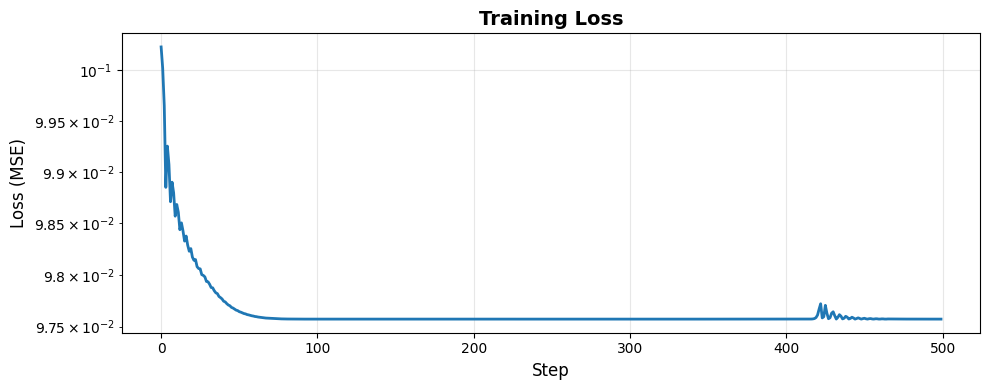

Initial loss: 1.002262e-01
Final loss: 9.757268e-02
Improvement: 1.0x


In [23]:
# Plot loss history
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training Loss', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.6e}")
print(f"Final loss: {losses[-1]:.6e}")
print(f"Improvement: {losses[0] / losses[-1]:.1f}x")